In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.seasonal import seasonal_decompose

In [2]:
df = pd.read_csv('2) Stock Prices Data Set.csv') 
df

,symbol,date,open,high,low,close,volume
0,AAL,2014-01-02,25.0700,25.8200,25.0600,25.3600,8998943
1,AAPL,2014-01-02,79.3828,79.5756,78.8601,79.0185,58791957
2,AAP,2014-01-02,110.3600,111.8800,109.2900,109.7400,542711
3,ABBV,2014-01-02,52.1200,52.3300,51.5200,51.9800,4569061
4,ABC,2014-01-02,70.1100,70.2300,69.4800,69.8900,1148391
...,...,...,...,...,...,...,...
497467,XYL,2017-12-29,68.5300,68.8000,67.9200,68.2000,1046677
497468,YUM,2017-12-29,82.6400,82.7100,81.5900,81.6100,1347613
497469,ZBH,2017-12-29,121.7500,121.9500,120.6200,120.6700,1023624
497470,ZION,2017-12-29,51.2800,51.5500,50.8100,50.8300,1261916


In [3]:
df.head(10)

,symbol,date,open,high,low,close,volume
0,AAL,2014-01-02,25.0700,25.8200,25.0600,25.3600,8998943
1,AAPL,2014-01-02,79.3828,79.5756,78.8601,79.0185,58791957
2,AAP,2014-01-02,110.3600,111.8800,109.2900,109.7400,542711
3,ABBV,2014-01-02,52.1200,52.3300,51.5200,51.9800,4569061
4,ABC,2014-01-02,70.1100,70.2300,69.4800,69.8900,1148391
5,ABT,2014-01-02,38.0900,38.4000,38.0000,38.2300,4967472
6,ACN,2014-01-02,81.5000,81.9200,81.0900,81.1300,2405384
7,ADBE,2014-01-02,59.0600,59.5300,58.9400,59.2900,2746370
8,ADI,2014-01-02,49.5200,49.7500,49.0400,49.2800,2799092
9,ADM,2014-01-02,43.2200,43.2900,42.7900,42.9900,2753765


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 497472 entries, 0 to 497471
Data columns (total 7 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   symbol  497472 non-null  object 
 1   date    497472 non-null  object 
 2   open    497461 non-null  float64
 3   high    497464 non-null  float64
 4   low     497464 non-null  float64
 5   close   497472 non-null  float64
 6   volume  497472 non-null  int64  
dtypes: float64(4), int64(1), object(2)
memory usage: 26.6+ MB


In [5]:
# Task 1 - Data Cleaning

# 1️. Handle missing values
df.isnull().sum()

symbol     0
date       0
open      11
high       8
low        8
close      0
volume     0
dtype: int64

In [6]:
# Fill missing numeric values with mean

num_cols = ['open','high','low']
df[num_cols] = df[num_cols].fillna(df[num_cols].mean())


In [7]:
df.isnull().sum()

symbol    0
date      0
open      0
high      0
low       0
close     0
volume    0
dtype: int64

In [10]:
# Drop rows where symbol or date is missing

df.dropna(subset = ['symbol','date'], inplace = True)

In [11]:
# 2️ .Remove duplicates

print("\nBefore Duplicate: ", df.duplicated().sum())

df.drop_duplicates(inplace = True)

print("\nAfter Duplicate: ",df.duplicated().sum())


Before Duplicate:  0

After Duplicate:  0


In [12]:
# 3. Fix inconsistent capitalization

df['symbol'] = df['symbol'].str.upper().str.strip()

In [13]:
# 4. Sort by symbol and date

df.sort_values(by = ['symbol','date'], inplace = True)

In [14]:
print("Clean DataSet Preview\n")
df.head(10)

Clean DataSet Preview



,symbol,date,open,high,low,close,volume
57,A,2014-01-02,57.10,57.100,56.150,56.21,1916160
540,A,2014-01-03,56.39,57.345,56.260,56.92,1866651
1023,A,2014-01-06,57.40,57.700,56.560,56.64,1777472
1506,A,2014-01-07,56.95,57.630,56.930,57.45,1463208
1989,A,2014-01-08,57.33,58.540,57.170,58.39,2659468
2472,A,2014-01-09,58.40,58.680,57.870,58.41,1757647
2955,A,2014-01-10,58.51,59.010,58.140,58.93,1623330
3438,A,2014-01-13,58.77,59.100,58.600,58.93,2946738
3921,A,2014-01-14,59.16,59.950,59.020,59.88,2562236
4404,A,2014-01-15,59.82,60.365,59.585,60.34,2335194


In [ ]:
# Task 2 - Exploratory Data Analysis (EDA)


In [15]:
# 1. Summary Statistics
df.describe()

,open,high,low,close,volume
count,497472.000000,497472.000000,497472.000000,497472.000000,4.974720e+05
mean,86.352275,87.132562,85.552467,86.369082,4.253611e+06
std,101.470106,102.311239,100.570148,101.472407,8.232139e+06
min,1.620000,1.690000,1.500000,1.590000,0.000000e+00
25%,41.690000,42.090000,41.280000,41.703750,1.080166e+06
50%,64.970000,65.560000,64.360000,64.980000,2.084896e+06
75%,98.410000,99.230000,97.580000,98.420000,4.271928e+06
max,2044.000000,2067.990000,2035.110000,2049.000000,6.182376e+08


In [16]:
# Mode and Median

print("\nMedian:\n", df.median(numeric_only=True))

print("\nMode:\n", df.mode().iloc[0])


Median:
 open           64.97
high           65.56
low            64.36
close          64.98
volume    2084896.50
dtype: float64

Mode:
 symbol             A
date      2017-12-05
open            70.0
high            72.0
low             77.0
close           34.5
volume     1241019.0
Name: 0, dtype: object


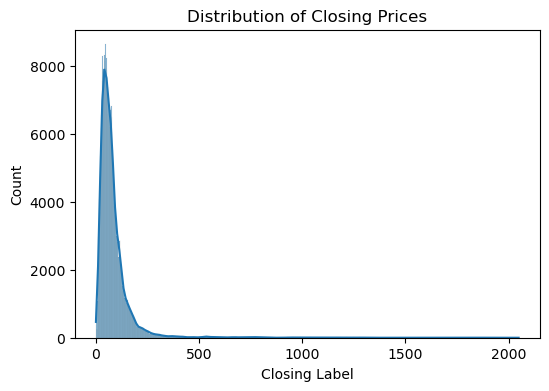

In [17]:
# Visualization - Distribution plot

plt.figure(figsize =(6,4))
sns.histplot(df['close'], kde = True)
plt.title("Distribution of Closing Prices")
plt.xlabel("Closing Label")
plt.show()


In [18]:
# Time Series Analysis


In [19]:
df.sort_values(by = 'date', inplace = True)

In [20]:
# Select one stock symbol for analysis

symbol = df['symbol'].unique()[0]

stock_df = df[df['symbol'] == symbol].copy()

In [21]:
# set date as index

stock_df.set_index('date', inplace = True)

In [22]:
# Display preview

print(stock_df.head())

           symbol   open    high    low  close   volume
date                                                   
2014-01-02      A  57.10  57.100  56.15  56.21  1916160
2014-01-03      A  56.39  57.345  56.26  56.92  1866651
2014-01-06      A  57.40  57.700  56.56  56.64  1777472
2014-01-07      A  56.95  57.630  56.93  57.45  1463208
2014-01-08      A  57.33  58.540  57.17  58.39  2659468


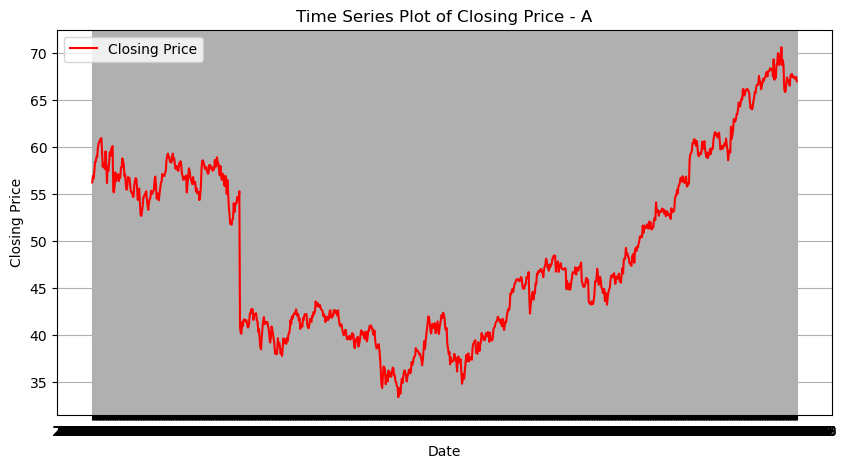

In [23]:
# Plot the Time-Series Data

plt.figure(figsize=(10,5))
plt.plot(stock_df['close'], label='Closing Price', color='red')
plt.title(f"Time Series Plot of Closing Price - {symbol}")
plt.xlabel("Date")
plt.ylabel("Closing Price")
plt.legend()
plt.grid(True)
plt.show()


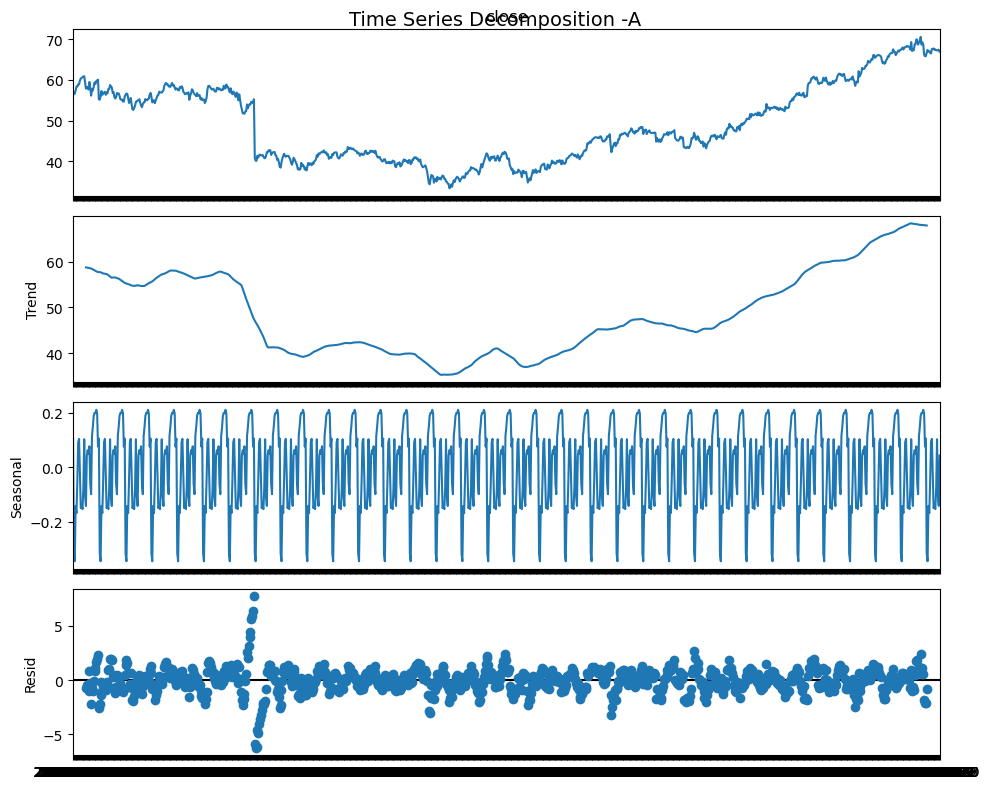

In [24]:
# Decompose the Series into Trend, Seasonality, and Residuals

# Perform seasonal decomposition
result = seasonal_decompose(stock_df['close'], model = 'additive', period = 30)

plt.rcParams.update({'figure.figsize':(10,8)})
result.plot()
plt.suptitle(f"Time Series Decomposition -{symbol}", fontsize = 14)
plt.show()

In [25]:
# Perform Moving Average Smoothing
# Calculate moving averages

stock_df['SMA_7'] = stock_df['close'].rolling(window=7).mean()   # 7-day moving average
stock_df['SMA_30'] = stock_df['close'].rolling(window=30).mean() # 30-day moving average


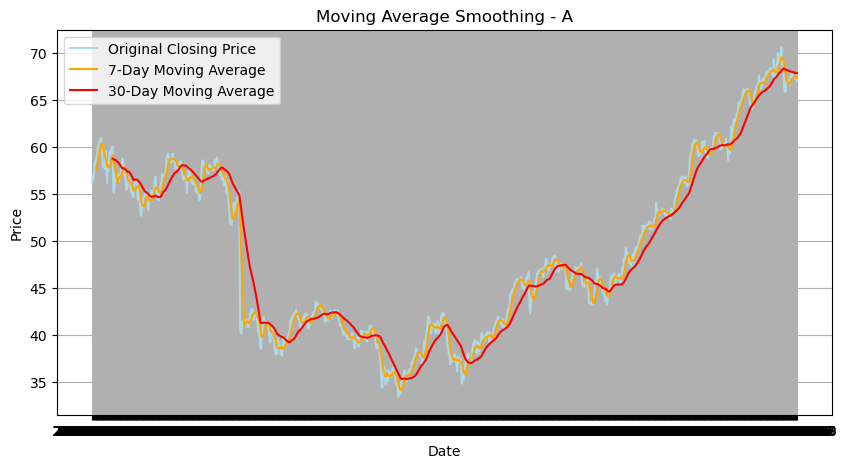

In [26]:
# Plot
plt.figure(figsize=(10,5))
plt.plot(stock_df['close'], label='Original Closing Price', color='lightblue')
plt.plot(stock_df['SMA_7'], label='7-Day Moving Average', color='orange')
plt.plot(stock_df['SMA_30'], label='30-Day Moving Average', color='red')
plt.title(f"Moving Average Smoothing - {symbol}")
plt.xlabel("Date")
plt.ylabel("Price")
plt.legend()
plt.grid(True)
plt.show()

In [27]:
# Correlation matrix

corr = df[['open', 'high', 'low', 'close', 'volume']].corr()
print("\nCorrelation Matrix:\n", corr)



Correlation Matrix:
             open      high       low     close    volume
open    1.000000  0.999941  0.999927  0.999856 -0.148724
high    0.999941  1.000000  0.999905  0.999918 -0.148344
low     0.999927  0.999905  1.000000  0.999922 -0.149284
close   0.999856  0.999918  0.999922  1.000000 -0.148839
volume -0.148724 -0.148344 -0.149284 -0.148839  1.000000


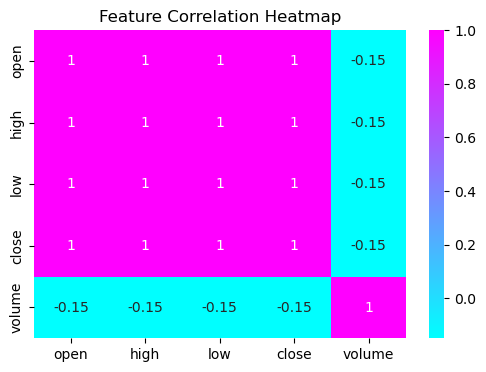

In [28]:
# Heatmap
plt.figure(figsize=(6,4))
sns.heatmap(corr, annot=True, cmap='cool')
plt.title("Feature Correlation Heatmap")
plt.show()

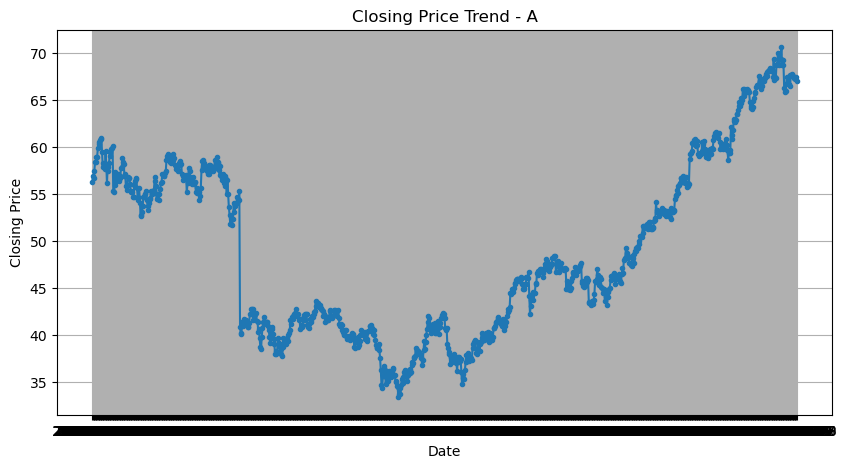

In [64]:
# Task 3 - Data Visualization

# 1️. Line chart of closing price over time for one stock

symbol = df['symbol'].unique()[0]
stock_df = df[df['symbol'] == symbol]

plt.figure(figsize=(10,5))
plt.plot(stock_df['date'], stock_df['close'], marker='.')
plt.title(f"Closing Price Trend - {symbol}")
plt.xlabel("Date")
plt.ylabel("Closing Price")
plt.grid(True)
plt.show()

In [43]:
# Task - Linear Regression 

# To predict closing prices based on open, high, low, and volume values.

In [44]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error,mean_squared_error, r2_score
# Features and target

X = df[['open','high','low','volume']]
y = df['close']   # closing prices

# split data
X_train, X_test, y_train, y_test = train_test_split(X, y , test_size = 0.2, random_state = 42)

lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

LinearRegression()

In [45]:
y_pred = lr_model.predict(X_test)

In [46]:
# Evaluation

print("Linear Regression performance\n")
print("MAE :",mean_absolute_error(y_test, y_pred))
print("RMSE :",np.sqrt(mean_squared_error(y_test, y_pred)))
print("R2 Score :",r2_score(y_test, y_pred))

Linear Regression performance

MAE : 0.35292225245245706
RMSE : 0.7424273438801987
R2 Score : 0.9999495039634255


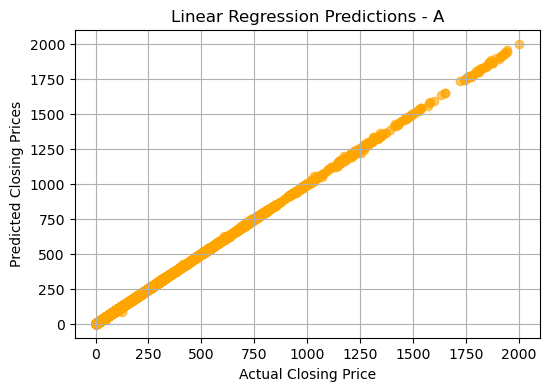

In [47]:
# Plot Actual Vs Predicted

plt.figure(figsize = (6,4))
plt.scatter(y_test, y_pred, color = 'orange', alpha = 0.6)
plt.xlabel("Actual Closing Price")
plt.ylabel("Predicted Closing Prices")
plt.title(f"Linear Regression Predictions - {symbol}")
plt.grid(True)
plt.show()